In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import pathlib
import gc
import warnings
warnings.filterwarnings('ignore')
import logging

from sklearn import metrics

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, Bidirectional, \
                        Conv1D, Flatten,MaxPooling1D, ConvLSTM2D, \
                        TimeDistributed, RepeatVector, Bidirectional, BatchNormalization
from keras.optimizers import Adam

seed = 42

tf.random.set_seed(seed)
np.random.seed(seed)

ROOT = pathlib.Path().resolve()
DATA_FOLDER = ROOT / "data/bike"
LOG_FILE = ROOT / "logs/info.log"

# logging.basicConfig(
#     filename=LOG_FILE,
#     format="%(asctime)s %(levelname)-8s %(message)s",
#     level=logging.INFO
# )

# Gets or creates a logger
train_log = logging.getLogger(__name__)  
train_log.setLevel(logging.INFO)

# define file handler and set formatter
file_handler = logging.FileHandler('logs/training_data.log')
formatter    = logging.Formatter('%(asctime)s : %(levelname)s : %(name)s : %(message)s')
file_handler.setFormatter(formatter)

# add file handler to logger
train_log.addHandler(file_handler)


print(DATA_FOLDER)

C:\Users\PatCa\Documents\PythonScripts\test_projects\big_data\bike_data\data\bike


In [3]:
df = pd.read_parquet('all_years_weekly.parquet')
# Log data
df['log_trips'] = df['count_trips'].apply(lambda x: np.log(x))

# Make stationary
df['log_trips_shift'] = df['log_trips'].diff()

In [4]:
df_weather = pd.read_parquet('all_weather_weekly.parquet')
print(df_weather.shape)
display(df_weather.head(3))

(314, 1)


,temp_avg
DATE,
2014-01-05,-4.430000
2014-01-12,-0.435714
2014-01-19,4.350000


In [5]:
df_comb = pd.merge(left=df, right=df_weather, how='left', left_index=True, right_on='DATE')
display(df_comb.head(4))

,count_trips,start_tripduration,log_trips,log_trips_shift,temp_avg
DATE,,,,,
2014-01-05,19855,16052099,9.896211,NaN,-4.430000
2014-01-12,66987,45280072,11.112254,1.216043,-0.435714
2014-01-19,107472,74364131,11.584986,0.472732,4.350000
2014-01-26,39418,30976679,10.581978,-1.003008,-5.950000


In [6]:
# Multi output step LSTM model
# Input is numpy arrays output is X[samples, in_stepn n_features], y[samples, in_stepn n_features]
def seq_multi_LSTM(sequence, n_input, n_output):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        if out_end_ix > len(sequence):
            break
        
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
    X = np.array(X)
    n_features = 1
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, np.array(y)


def print_curves(history, train_met, test_met):
    plt.figure()
    plt.plot(history.history[train_met], label='train')
    plt.plot(history.history[test_met], label='test')
    plt.title(train_met)
    plt.legend()
    plt.show()
    return


def lstm_model(Xtrain, n1=25, n2=25, n3= 25, lr=0.001):
    model = Sequential()
    model.add(LSTM(n1, activation='relu', return_sequences=True, input_shape=(Xtrain.shape[1], Xtrain.shape[2]), name='LSTM1'))
    model.add(LSTM(n2, activation='relu', name="LSTM2"))
    model.add(Dense(n3, name='Dense_out'))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics='mae')
    return model


def pred_check(y_pred, y_true, y_train):
    pred_length = y_pred.shape[0]
    pred_date = df.iloc[-pred_length:,:].index
    train_length = y_train.shape[0]
    train_date = df.iloc[:train_length:,:].index
    
    ev = metrics.explained_variance_score(y_true, y_pred)
    mape_ = metrics.mean_absolute_percentage_error(y_true, y_pred)
    mae_ = metrics.mean_absolute_error(y_true, y_pred)
    rms = np.sqrt(metrics.mean_squared_error(y_true, y_pred))

    print(f'explained variance: {ev:.2f}, mape: {mape_:.2f}, mae: {mae_:.2f}, rms: {rms:.2f}')

    plt.figure()
    plt.plot(train_date, y_train)
    plt.plot(pred_date, y_pred, color='orange')
    plt.plot(pred_date, y_true, color='purple', alpha=0.2)
    plt.show()
    return


## LSTM one-period walk-forward prediction test

In [ ]:
n_input = 12
n_output = 1

test_length = int(df_comb.shape[0] * 0.1)
train = df_comb.iloc[:-test_length,:].dropna()
test = df_comb.iloc[-test_length:,:].dropna()

print(train.shape, test.shape)
display(train.head(5))

Xtrain, ytrain = seq_multi_LSTM(train['log_trips_shift'], n_input, n_output)
Xtest, ytest = seq_multi_LSTM(test['log_trips_shift'], n_input, n_output)

In [ ]:
#-------------------------- Basic multi step output LSTM -----------------------------------------------------
LSTM1_UNITS = 100
LSTM2_UNITS = 50
DENSE_OUT_UNITS = n_output

LEARNING_RATE = 0.005

model = lstm_model(Xtrain, n1=LSTM1_UNITS, n2=LSTM2_UNITS, n3=DENSE_OUT_UNITS, lr=LEARNING_RATE)

layer_data = [[LSTM1_UNITS], [LSTM2_UNITS], [DENSE_OUT_UNITS]]
model_layers = [layer.name for layer in model.layers]
layer_dict = {name: layer_data[i] for i,name in enumerate(model_layers)}

In [ ]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

model_desc = "LSTM"
BATCH_SIZE = 128
EPOCHS = 10

history = model.fit(Xtrain, ytrain, batch_size=BATCH_SIZE, epochs=EPOCHS,
                    validation_data=(Xtest, ytest), verbose=1,
                    callbacks=[])

print_curves(history, 'loss', 'val_loss')
print_curves(history, 'mae', 'val_mae')

In [ ]:
result_dict = {}
result_dict = {name: round(history.history[name][-1],4) for name in history.history.keys()}

train_log.info(f"Model: {model_desc}, Layer_data: {layer_dict}, Learning_rate: {LEARNING_RATE} Batch_size: {BATCH_SIZE}, EPOCHS:{EPOCHS}, Result: {result_dict}")


In [ ]:
# Predict test data
Xtest_all = np.concatenate((Xtrain[-12:,:,:], Xtest), axis=0)
ytest_all = test['log_trips_shift'].to_numpy()
ytest_all = ytest_all[:, np.newaxis]

print(Xtest_all.shape, ytest_all.shape)

In [ ]:
y_pred = model.predict(Xtest_all)
y_pred_detrans = np.exp(train.iloc[-1,2] + y_pred[:,0].cumsum())

pred_check(y_pred_detrans, test['count_trips'], train['count_trips'])

## CNN

In [7]:
# Multi output step CNN model
# Input is numpy arrays output is X[samples, in_step, features], y[samples]
def multivar_LSTM(sequence, n_input, n_output):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        
        if out_end_ix > len(sequence):
            break
        
        seq_x, seq_y = sequence.iloc[i:end_ix,:], sequence.iloc[end_ix:out_end_ix,0]
        X.append(seq_x)
        y.append(seq_y)
    X = np.array(X)
    n_features = sequence.shape[1]
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, np.array(y)

In [20]:
n_input = 12
n_output = 4

test_length = int(df_comb.shape[0] * 0.1)
train = df_comb.iloc[:-test_length,:].dropna()
test = df_comb.iloc[-test_length:,:].dropna()

print(train.shape, test.shape)
display(train.head(5))

Xtrain, ytrain = seq_multi_LSTM(train['log_trips_shift'], n_input, n_output)
Xtest, ytest = seq_multi_LSTM(test['log_trips_shift'], n_input, n_output)

print(Xtrain.shape, ytrain.shape)

(282, 5) (31, 5)


,count_trips,start_tripduration,log_trips,log_trips_shift,temp_avg
DATE,,,,,
2014-01-12,66987,45280072,11.112254,1.216043,-0.435714
2014-01-19,107472,74364131,11.584986,0.472732,4.350000
2014-01-26,39418,30976679,10.581978,-1.003008,-5.950000
2014-02-02,84278,60393006,11.341876,0.759898,-1.014286
2014-02-09,40244,38013273,10.602716,-0.739160,-1.807143


(267, 12, 1) (267, 4)


In [9]:
def cnn_model(Xtrain, n_output, n1=50, n2=50, n3= 25, n_nodes= 25, d_out=0.2, lr=0.001):
    model = Sequential()
    model.add(Conv1D(n1, 6, activation='relu', input_shape=(Xtrain.shape[1], Xtrain.shape[2])))
    model.add(MaxPooling1D(3))
    model.add(Flatten())
    #model.add(Dropout(d_out))
    #model.add(Dense(n2, activation='relu'))
    #model.add(Dropout(d_out))
    model.add(Dense(n_output))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics='mae')
    print(model.summary())
    return model

In [10]:
#-------------------------- Basic multi step output LSTM -----------------------------------------------------
model = cnn_model(Xtrain, n_output, n1=10, n2=10, n_nodes=50, d_out=0.3, lr=0.0001)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 7, 10)             70        
                                                                 
 max_pooling1d (MaxPooling1D  (None, 2, 10)            0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 20)                0         
                                                                 
 dense (Dense)               (None, 4)                 84        
                                                                 
Total params: 154
Trainable params: 154
Non-trainable params: 0
_________________________________________________________________
None


Epoch 1/1000
5/5 [==============================] - 5s 115ms/step - loss: 0.0867 - mae: 0.2058 - val_loss: 0.0539 - val_mae: 0.1390
Epoch 2/1000
5/5 [==============================] - 0s 18ms/step - loss: 0.0860 - mae: 0.2046 - val_loss: 0.0535 - val_mae: 0.1382
Epoch 3/1000
5/5 [==============================] - 0s 17ms/step - loss: 0.0852 - mae: 0.2033 - val_loss: 0.0531 - val_mae: 0.1375
Epoch 4/1000
5/5 [==============================] - 0s 18ms/step - loss: 0.0845 - mae: 0.2021 - val_loss: 0.0528 - val_mae: 0.1368
Epoch 5/1000
5/5 [==============================] - 0s 17ms/step - loss: 0.0838 - mae: 0.2009 - val_loss: 0.0525 - val_mae: 0.1361
Epoch 6/1000
5/5 [==============================] - 0s 17ms/step - loss: 0.0831 - mae: 0.1998 - val_loss: 0.0522 - val_mae: 0.1354
Epoch 7/1000
5/5 [==============================] - 0s 18ms/step - loss: 0.0825 - mae: 0.1988 - val_loss: 0.0518 - val_mae: 0.1347
Epoch 8/1000
5/5 [==============================] - 0s 16ms/step - loss: 0.0819 - 

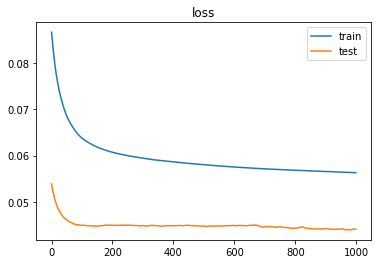

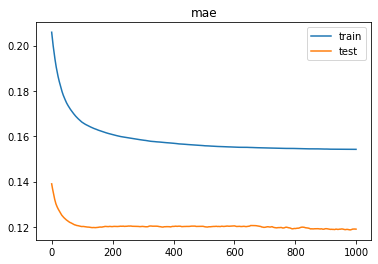

In [11]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(Xtrain, ytrain, batch_size=64, epochs=1000,
                    validation_data=(Xtest, ytest), verbose=1,
                    callbacks=[])

print_curves(history, 'loss', 'val_loss')
print_curves(history, 'mae', 'val_mae')

## Residual Error
1. Calculate residual error
2. Analyze
3. Treat

In [28]:
# Predict dataset
n_totput = n_input + n_output

pred_data1 = train.iloc[-n_input:,:]
test_test_df = pd.concat([pred_data1,test],axis=0)
pred_data = test_test_df[['log_trips_shift']]
print(pred_data.shape)

#no_samples = (pred_data.shape[0] - n_output) - n_input + 1
#pred_X = pred_data.iloc[:-n_output,:].to_numpy().reshape(no_samples,n_input,1)
#pred_y = pred_data.iloc[n_input:,:].to_numpy().reshape(no_samples,n_output)

Xpred, ytrue = seq_multi_LSTM(test_test_df['log_trips_shift'], n_input, n_output)

print(Xpred.shape, ytrue.shape)


(43, 1)
(28, 12, 1) (28, 4)


In [29]:
def plot_multi(y_pred):
    pred_time = y_pred_detrans.shape[0]
    
    ev = metrics.explained_variance_score(test.iloc[-pred_time:,0], y_pred)
    mape_ = metrics.mean_absolute_percentage_error(test.iloc[-pred_time:,0], y_pred)
    mae_ = metrics.mean_absolute_error(test.iloc[-pred_time:,0], y_pred)
    rms = np.sqrt(metrics.mean_squared_error(test.iloc[-pred_time:,0], y_pred))

    print(f'explained variance: {ev:.2f}, mape: {mape_:.2f}, mae: {mae_:.2f}, rms: {rms:.2f}')
    
    plt.figure()
    plt.plot(train.index, train['count_trips'])
    plt.plot(test.index, test['count_trips'], color='purple', alpha=0.2)
    plt.plot(test.iloc[-pred_time:,:].index, y_pred)
    plt.show()
    
    return

In [32]:
y_pred = model.predict(Xpred)

print(y_pred.shape)
# y_pred = y_pred.reshape(n_output,1)

# y_pred_detrans = np.exp(test.iloc[-(n_totput+1),2] + y_pred[:,0].cumsum())
# print(y_pred_detrans)

# plot_multi(y_pred_detrans)

1/1 [==============================] - 0s 39ms/step
(28, 4)


## Multistep LSTM


In [ ]:
# Multi output step LSTM model
# Input is numpy arrays output is X[samples, in_step], y[samples]
def multivar_LSTM(sequence, n_input, n_output):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        
        if out_end_ix > len(sequence):
            break
        
        seq_x, seq_y = sequence.iloc[i:end_ix,:], sequence.iloc[end_ix:out_end_ix,0]
        X.append(seq_x)
        y.append(seq_y)
    X = np.array(X)
    n_features = sequence.shape[1]
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, np.array(y)

In [ ]:
n_input = 12
n_output = 4

Xtrain, ytrain = multivar_LSTM(train[['log_trips_shift','temp_avg']], n_input, n_output)
Xtest, ytest = multivar_LSTM(test[['log_trips_shift','temp_avg']], n_input, n_output)


In [ ]:
#-------------------------- Basic multi step output LSTM -----------------------------------------------------
model = lstm_model(Xtrain, n_output, n1=50, n2=50, d_out=0.2, lr=0.01)

In [ ]:
from keras.callbacks import ModelCheckpoint,ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.7,
                              patience=5, min_lr=0.001)

history = model.fit(Xtrain, ytrain, batch_size=64, epochs=150,
                    validation_data=(Xtest, ytest), verbose=1,
                    callbacks=[reduce_lr])

print_curves(history, 'loss', 'val_loss')
print_curves(history, 'mae', 'val_mae')

In [ ]:
# Predict test data
Xtest_all = np.concatenate((Xtrain[-12:,:,:], Xtest), axis=0)
ytest_all = test['log_trips_shift'].to_numpy()
ytest_all = ytest_all[:, np.newaxis]

print(Xtest_all.shape, ytest_all.shape)


In [ ]:
y_pred = model.predict(Xtest_all)
y_pred_detrans = np.exp(train.iloc[-1,2] + y_pred[:,0].cumsum())

pred_check(y_pred_detrans, test['count_trips'], train['count_trips'])

## Test CNN/LSTM

In [ ]:
# Multi output step CNN-LSTM model
# Input is numpy arrays, output is X[samples, subsamples, in_step, features], y[samples]
def seq_multi_CNNLSTM(sequence, n_input, n_output):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        if out_end_ix > len(sequence):
            break
        
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    n_features = 1
    n_seq = 2
    n_steps = int(n_input/n_seq)
    X = X.reshape((X.shape[0], n_seq, n_steps, n_features))
    
    return X, np.array(y)

def cnn_model(Xtrain, n_output, n1=25, n2=25, n3= 25, n_nodes= 25, d_out=0.2, lr=0.001):
    model = Sequential()
    model.add(TimeDistributed(Conv1D(128,1,activation='relu', input_shape=(None,Xtrain.shape[2], Xtrain.shape[3]))))
    model.add(TimeDistributed(MaxPooling1D()))
    model.add(TimeDistributed(Conv1D(64,1,activation='relu')))
    model.add(TimeDistributed(MaxPooling1D()))
    model.add(TimeDistributed(Flatten()))
    
    model.add(LSTM(100, activation='relu', return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(100, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(n_output))
    
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics='mae')
    
    return model



In [ ]:
n_input = 12
n_output = 1

test_length = int(df_comb.shape[0] * 0.1)
train = df_comb.iloc[:-test_length,:].dropna()
test = df_comb.iloc[-test_length:,:].dropna()

print(train.shape, test.shape)
display(train.head(5))

Xtrain, ytrain = seq_multi_CNNLSTM(train['log_trips_shift'], n_input, n_output)
Xtest, ytest = seq_multi_CNNLSTM(test['log_trips_shift'], n_input, n_output)

print(Xtrain.shape, ytrain.shape)

In [ ]:
#-------------------------- Basic multi step output LSTM -------------------------------------------------
model = cnn_model(Xtrain, n_output, n1=100, n2=50, n_nodes=50, d_out=0.0, lr=0.0005)

In [ ]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(Xtrain, ytrain, batch_size=128, epochs=500,
                    validation_data=(Xtest, ytest), verbose=1,
                    callbacks=[])

print_curves(history, 'loss', 'val_loss')
print_curves(history, 'mae', 'val_mae')

## Encode-Decoder LSTM
Multistep autoencoder

In [ ]:
# Multi output encoder-decoder
# Input is numpy arrays, output is X[samples, in_step, features], y[samples, in_step, features]
def autoreg_lstm_data(sequence, n_input, n_output):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        if out_end_ix > len(sequence):
            break
        
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)
    n_features = 1
    X = X.reshape((X.shape[0], X.shape[1], n_features))
    y = y.reshape((y.shape[0], y.shape[1], n_features))
    
    return X, y

def autoreg_lstm_model(Xtrain, n_output, n1=50, n2=50, n3= 100, n_nodes= 25, d_out=0.2, lr=0.001):
    model = Sequential()
    model.add(LSTM(n1, activation='relu', return_sequences=True, input_shape=(Xtrain.shape[1], Xtrain.shape[2])))
    model.add(LSTM(n1, activation='relu'))  #, input_shape=(Xtrain.shape[1], Xtrain.shape[2])))
    #model.add(Dropout(d_out))
    model.add(RepeatVector(n_output))
    model.add(LSTM(n2, activation='relu', return_sequences=True))
    #model.add(Dropout(d_out))
    model.add(TimeDistributed(Dense(units=n3,activation='relu')))
    #model.add(TimeDistributed(Dropout(d_out)))
    model.add(TimeDistributed(Dense(1)))
    
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics='mae')
    
    return model



In [ ]:
n_input = 12
n_output = 1

test_length = int(df_comb.shape[0] * 0.1)
train = df_comb.iloc[:-test_length,:].dropna()
test = df_comb.iloc[-test_length:,:].dropna()

print(train.shape, test.shape)
display(train.head(5))

Xtrain, ytrain = autoreg_lstm_data(train['log_trips_shift'], n_input, n_output)
Xtest, ytest = autoreg_lstm_data(test['log_trips_shift'], n_input, n_output)

print(Xtrain.shape, ytrain.shape)

In [ ]:
#-------------------------- Basic multi step output LSTM -------------------------------------------------
model = autoreg_lstm_model(Xtrain, n_output, n1=50, n2=50, n_nodes=50, d_out=0.0, lr=0.01)

In [ ]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(Xtrain, ytrain, batch_size=64, epochs=100,
                    validation_data=(Xtest, ytest), verbose=1,
                    callbacks=[])

print_curves(history, 'loss', 'val_loss')
print_curves(history, 'mae', 'val_mae')

## Encoder-Decoder ConvLSTM test

In [ ]:
# Multi output encoder-decoder for ConvLSTM
# Input is numpy arrays, dim depende on the ConvLSTM layer  X[samples, subseq, kerel_row, kernel_col, features]
# output is numpy, dim depends on the encode-decoder design, output is a vector y[samples, in_step, features]
def autoreg_lstm_data(sequence, n_input, n_output):
    X, y = [], []
    
    for i in range(len(sequence)):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        if out_end_ix > len(sequence):
            break
        
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)
    n_features = 1
    row_kern = 1
    col_kernel = 2
    sub_seq = int(X.shape[1]/col_kernel)
    X = X.reshape((X.shape[0], sub_seq, 1, col_kernel, n_features))
    y = y.reshape((y.shape[0], y.shape[1], n_features))
    
    return X, y

def autoreg_convlstm_model(Xtrain, n_output, n1=64, n2=100, n3= 100, n_nodes= 25, d_out=0.2, lr=0.001):
    model = Sequential()
    model.add(ConvLSTM2D(n1, (1,2), activation='relu', return_sequences=True, input_shape=(Xtrain.shape[1], 1, Xtrain.shape[3], Xtrain.shape[4]))) #, return_sequences=True
    #model.add(BatchNormalization())
    model.add(ConvLSTM2D(int(n1/2), (1,1), activation='relu', return_sequences=True))
    model.add(Flatten())
    #model.add(Dropout(d_out))
    model.add(RepeatVector(n_output))
    model.add(Bidirectional(LSTM(n2, activation='relu', return_sequences=True)))
    #model.add(Dropout(d_out))
    model.add(Bidirectional(LSTM(n2, activation='relu', return_sequences=True)))
    model.add(TimeDistributed(Dense(units=n3,activation='relu')))
    #model.add(TimeDistributed(Dropout(d_out)))
    model.add(TimeDistributed(Dense(1)))
    
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics='mae')
    #print(model.summary())
    
    return model



In [ ]:
n_input = 12
n_output = 1

test_length = int(df_comb.shape[0] * 0.1)
train = df_comb.iloc[:-test_length,:].dropna()
test = df_comb.iloc[-test_length:,:].dropna()

print(train.shape, test.shape)
display(train.head(5))

Xtrain, ytrain = autoreg_lstm_data(train['log_trips_shift'], n_input, n_output)
Xtest, ytest = autoreg_lstm_data(test['log_trips_shift'], n_input, n_output)

print(Xtrain.shape, ytrain.shape)

In [ ]:
#-------------------------- Basic multi step output LSTM -------------------------------------------------
model = autoreg_convlstm_model(Xtrain, n_output, n1=64, n2=100, n_nodes=100, d_out=0.0, lr=0.0001)

In [ ]:
print(model.summary())

In [ ]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(Xtrain, ytrain, batch_size=64, epochs=200,
                    validation_data=(Xtest, ytest), verbose=1,
                    callbacks=[])

print_curves(history, 'loss', 'val_loss')
print_curves(history, 'mae', 'val_mae')